# Assignment 3

Deadline: 22.04.2026 12:00 CET

- Gallo Alessandro , 25-732-140 , alessandro.gallo2@uzh.ch
- Maruccio Anna , 25-742-800 , anna.maruccio@uzh.ch
- Perbellini Cesare, 25-741-257, cesare.perbellini@uzh.ch
- Venturi Matilde , 25-741-059 , matilde.venturi@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [22]:
# Standard library imports
import os
import sys
import copy
from typing import Optional


# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
# Import local modules
project_root = os.path.dirname(os.getcwd())   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course', 'src') #changed for Macbook
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [23]:
PATH_TO_DATA = project_root + '/qpmwp-course/data_backtesting_assignment3/' # <CHANGE THIS TO YOUR PATH TO DATA> 

In [24]:

# Load market and jkp data from parquet files
import pyarrow.parquet as pq

table_market = pq.read_table(f"{PATH_TO_DATA}market_data.parquet")
table_jkp = pq.read_table(f"{PATH_TO_DATA}jkp_data.parquet")

market_data = table_market.to_pandas(strings_to_categorical=False)
jkp_data = table_jkp.to_pandas(strings_to_categorical=False) #dati per costruire factors 

# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path= project_root + '/qpmwp-course/data/')

In [25]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [26]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']

        # Store the sample estimates once so that solve() can repeatedly
        # update only the risk-aversion parameter.
        self._covmat = np.asarray(
            self.covariance.estimate(X=X, inplace=False),
            dtype=float,
        )
        self._mu = np.asarray(
            self.expected_return.estimate(X=X, inplace=False),
            dtype=float,
        ).reshape(-1)

        risk_aversion = float(self.params.get('risk_aversion', 1.0))

        # qpsolvers minimizes 0.5 * w'Pw + q'w.
        # To match the assignment objective
        #     -mu'w + (lambda / 2) * w'Sigma w,
        # we therefore set q = -mu and P = lambda * Sigma.
        self.objective = Objective(
            q=-self._mu,
            P=risk_aversion * self._covmat,
        )
        return None

    def solve(self) -> None:
        max_iter = int(self.params.get('max_iter', 10))
        tol = float(self.params.get('tol', 1e-8))
        risk_aversion = float(self.params.get('risk_aversion', 1.0))

        mu = self._mu
        covmat = self._covmat

        history = []
        best_results = None
        best_sharpe = -np.inf
        best_risk_aversion = risk_aversion
        best_iteration = None

        for iteration in range(max_iter):
            self.objective = Objective(
                q=-mu,
                P=risk_aversion * covmat,
            )

            super().solve()
            current_results = copy.deepcopy(self.results)

            w = (
                pd.Series(current_results['weights'])
                .reindex(self.constraints.ids)
                .fillna(0.0)
                .to_numpy(dtype=float)
            )

            port_return = float(mu @ w)
            port_var = float(w @ covmat @ w)

            if port_var <= 0:
                break

            sharpe = port_return / np.sqrt(port_var)
            history.append(
                {
                    'iteration': iteration,
                    'risk_aversion': risk_aversion,
                    'expected_return': port_return,
                    'variance': port_var,
                    'sharpe': sharpe,
                }
            )

            # Keep the best portfolio seen so far rather than returning the
            # last iterate, which may be slightly worse if the update overshoots.
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_results = current_results
                best_risk_aversion = risk_aversion
                best_iteration = iteration

            # Fixed-point update for the assignment objective.
            # At the tangency portfolio, lambda = (mu'w) / (w'Sigma w).
            new_risk_aversion = port_return / port_var

            if abs(new_risk_aversion - risk_aversion) <= tol * max(1.0, abs(risk_aversion)):
                break

            risk_aversion = new_risk_aversion

        if best_results is None:
            raise RuntimeError('MaxSharpe did not produce a valid iterate.')

        self.params['risk_aversion'] = best_risk_aversion
        self.results = best_results
        self.results['risk_aversion'] = best_risk_aversion
        self.results['best_iteration'] = best_iteration
        self.results['best_sharpe'] = best_sharpe
        self.results['history'] = pd.DataFrame(history)

        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [27]:
# bs.optimization = MaxSharpe(
#     covariance=Covariance(method='pearson'),
#     expected_return=ExpectedReturn(method='geometric'),
#     solver_name='cvxopt',  # <change this to your preferred solver>
#     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
# )
# bs.prepare_rebalancing(rebdates[-1])
# bs.optimization.set_objective(bs.optimization_data)
# bs.optimization.solve()

# bs.optimization.results

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


### Calibration Workflow

To calibrate the turnover penalty, we proceed in four steps.

1. Define the calibration inputs and helper functions.
2. Run a coarse log-scale search on the full set of rebalancing dates.
3. Recompute the two bracket endpoints with the final search settings.
4. Refine the bracket with log-space bisection and validate the chosen penalty on the final backtest.


In [28]:
# Calibration inputs and helper functions.

target_turnover = 1.0
calibration_solver = 'osqp'

# Use the full rebalancing schedule throughout the search.
search_rebdates = rebdates
search_return_series = data.get_return_series(weekdays_only=False)
search_rebdates_dt = pd.to_datetime(search_rebdates)
search_rebal_per_year = 365.25 / np.median(
    np.diff(search_rebdates_dt).astype('timedelta64[D]').astype(int)
)

# Start with a small log-spaced grid to locate a penalty interval
# that brackets the target turnover.
coarse_search_penalties = np.geomspace(1e-6, 1e-2, 4)

# Use the same solver effort in the coarse and refinement stages so that
# the turnover estimates are directly comparable across all evaluations.
coarse_search_max_iter = 10
coarse_search_tol = 1e-8
refinement_max_iter = 10
refinement_tol = 1e-8

# Refine the bracket with a fixed number of log-space bisection updates.
n_bisection_steps = 10


# Choose whether to print the rebalancing dates during the search
show_rebalancing_dates = False
turnover_search_cache = {}

# These helpers keep the turnover calibration logic in one place and avoid
# repeating the same backtest / bracket-search code in the cells below.
def evaluate_turnover_penalty(penalty, max_iter, tol):
    penalty = float(penalty)
    cache_key = (penalty, int(max_iter), float(tol))

    # Reuse previously computed results when the same configuration is evaluated again.
    if cache_key in turnover_search_cache:
        return turnover_search_cache[cache_key]

    # Build a temporary backtest service dedicated to this penalty evaluation.
    bs_tmp = BacktestService(
        data=data,
        selection_item_builders=copy.deepcopy(selection_item_builders),
        optimization_item_builders=copy.deepcopy(optimization_item_builders),
        rebdates=search_rebdates,
        quiet=not show_rebalancing_dates,
    )

    # Plug the candidate turnover penalty into the optimization problem.
    bs_tmp.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name=calibration_solver,
        turnover_penalty=penalty,
        risk_aversion=1.0,
        max_iter=int(max_iter),
        tol=float(tol),
    )

    bt_tmp = Backtest()

    # Run the full backtest on all search rebalancing dates.
    bt_tmp.run(bs=bs_tmp)

    # Convert average per-rebalance turnover into an annualized figure.
    turnover = bt_tmp.strategy.turnover(return_series=search_return_series)
    annualized_turnover = float(turnover.iloc[1:].mean() * search_rebal_per_year)

    # Store the result so repeated calls with the same inputs are instant.
    turnover_search_cache[cache_key] = annualized_turnover
    return annualized_turnover


def find_turnover_bracket(search_df, target):
    lower_penalty = None
    upper_penalty = None

    # Look for two consecutive penalties whose turnovers fall on opposite
    # sides of the target, so the solution is bracketed between them.
    for i in range(len(search_df) - 1):
        left_error = search_df.loc[i, 'annualized_turnover'] - target
        right_error = search_df.loc[i + 1, 'annualized_turnover'] - target

        if left_error == 0 or left_error * right_error < 0:
            lower_penalty = float(search_df.loc[i, 'turnover_penalty'])
            upper_penalty = float(search_df.loc[i + 1, 'turnover_penalty'])
            break

    # If no sign change is found, the coarse grid must be widened.
    if lower_penalty is None:
        raise ValueError(
            'The coarse search does not bracket the 100% turnover target. ' +
            'Inspect coarse_df and widen the search range if needed.'
        )

    return lower_penalty, upper_penalty


In [29]:
# Step 1: run a coarse search on all rebalancing dates to locate
# a bracket around the target turnover.

coarse_results = []

for penalty in coarse_search_penalties:
    annualized_turnover = evaluate_turnover_penalty(
        penalty=penalty,
        max_iter=coarse_search_max_iter,
        tol=coarse_search_tol,
    )
    print(
        f"Coarse search | penalty = {penalty:.2e} | "
        f"annualized turnover = {annualized_turnover:.4f}"
    )

    coarse_results.append({
        'turnover_penalty': float(penalty),
        'annualized_turnover': float(annualized_turnover),
    })

coarse_df = (
    pd.DataFrame(coarse_results)
    .sort_values('turnover_penalty')
    .reset_index(drop=True)
)
display(coarse_df)

lower_penalty, upper_penalty = find_turnover_bracket(coarse_df, target_turnover)

print(f'Coarse-search bracket: [{lower_penalty:.2e}, {upper_penalty:.2e}]')


Coarse search | penalty = 1.00e-06 | annualized turnover = 1.8263
Coarse search | penalty = 2.15e-05 | annualized turnover = 1.5163
Coarse search | penalty = 4.64e-04 | annualized turnover = 0.3856
Coarse search | penalty = 1.00e-02 | annualized turnover = 0.0935


,turnover_penalty,annualized_turnover
0,0.000001,1.826333
1,0.000022,1.516336
2,0.000464,0.385607
3,0.010000,0.093497


Coarse-search bracket: [2.15e-05, 4.64e-04]


In [30]:
# Step 2: recompute the two coarse-search endpoints with the final
# search settings before starting the bisection.

lower_turnover = evaluate_turnover_penalty(
    lower_penalty,
    max_iter=refinement_max_iter,
    tol=refinement_tol,
)
upper_turnover = evaluate_turnover_penalty(
    upper_penalty,
    max_iter=refinement_max_iter,
    tol=refinement_tol,
)

bounds_df = pd.DataFrame([
    {'turnover_penalty': lower_penalty, 'annualized_turnover': float(lower_turnover)},
    {'turnover_penalty': upper_penalty, 'annualized_turnover': float(upper_turnover)},
]).sort_values('turnover_penalty').reset_index(drop=True)

display(bounds_df)
print(
    f"Lower Bound - Deep search | penalty = {lower_penalty:.2e} | "
    f"annualized turnover = {lower_turnover:.4f}"
)
print(
    f"Upper Bound - Deep search | penalty = {upper_penalty:.2e} | "
    f"annualized turnover = {upper_turnover:.4f}"
)


,turnover_penalty,annualized_turnover
0,0.000022,1.516336
1,0.000464,0.385607


Lower Bound - Deep search | penalty = 2.15e-05 | annualized turnover = 1.5163
Upper Bound - Deep search | penalty = 4.64e-04 | annualized turnover = 0.3856


In [31]:
# Step 3: refine the bracket with log-space bisection.

deep_results = bounds_df.to_dict(orient='records')

f_low = lower_turnover - target_turnover
f_high = upper_turnover - target_turnover

if f_low * f_high > 0:
    raise ValueError(
        'The deep-search bracket does not contain the target turnover. ' +
        'Choose a wider interval around the best coarse penalties.'
    )

log_low = np.log(lower_penalty)
log_high = np.log(upper_penalty)

for _ in range(n_bisection_steps):
    mid_penalty = float(np.exp((log_low + log_high) / 2))
    mid_turnover = evaluate_turnover_penalty(
        mid_penalty,
        max_iter=refinement_max_iter,
        tol=refinement_tol,
    )
    f_mid = mid_turnover - target_turnover
    print(
        f"Deep search | penalty = {mid_penalty:.2e} | "
        f"annualized turnover = {mid_turnover:.4f}"
    )

    deep_results.append({
        'turnover_penalty': mid_penalty,
        'annualized_turnover': float(mid_turnover),
    })

    if f_low * f_mid <= 0:
        log_high = np.log(mid_penalty)
        f_high = f_mid
    else:
        log_low = np.log(mid_penalty)
        f_low = f_mid

deep_df = (
    pd.DataFrame(deep_results)
    .sort_values('turnover_penalty')
    .drop_duplicates('turnover_penalty')
    .reset_index(drop=True)
)
best_idx = (deep_df['annualized_turnover'] - target_turnover).abs().idxmin()
best_turnover_penalty = float(deep_df.loc[best_idx, 'turnover_penalty'])
best_turnover_deep = float(deep_df.loc[best_idx, 'annualized_turnover'])

display(deep_df)
print(f'Chosen deep-search penalty: {best_turnover_penalty:.8f}')
print(f'Estimated annualized turnover on the full calibration schedule: {best_turnover_deep:.4f}')


Deep search | penalty = 1.00e-04 | annualized turnover = 1.0673
Deep search | penalty = 2.15e-04 | annualized turnover = 0.7473
Deep search | penalty = 1.47e-04 | annualized turnover = 0.8788
Deep search | penalty = 1.21e-04 | annualized turnover = 0.9793
Deep search | penalty = 1.10e-04 | annualized turnover = 1.0085
Deep search | penalty = 1.15e-04 | annualized turnover = 0.9893
Deep search | penalty = 1.13e-04 | annualized turnover = 1.0120
Deep search | penalty = 1.14e-04 | annualized turnover = 0.9984
Deep search | penalty = 1.13e-04 | annualized turnover = 0.9916
Deep search | penalty = 1.13e-04 | annualized turnover = 0.9940


,turnover_penalty,annualized_turnover
0,0.000022,1.516336
1,0.000100,1.067308
2,0.000110,1.008450
3,0.000113,1.012025
4,0.000113,0.993978
5,0.000113,0.991649
6,0.000114,0.998384
7,0.000115,0.989309
8,0.000121,0.979286
9,0.000147,0.878773


Chosen deep-search penalty: 0.00011410
Estimated annualized turnover on the full calibration schedule: 0.9984


Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

<Axes: title={'center': 'Turnover on the Full Backtest'}, xlabel='turnover_penalty'>

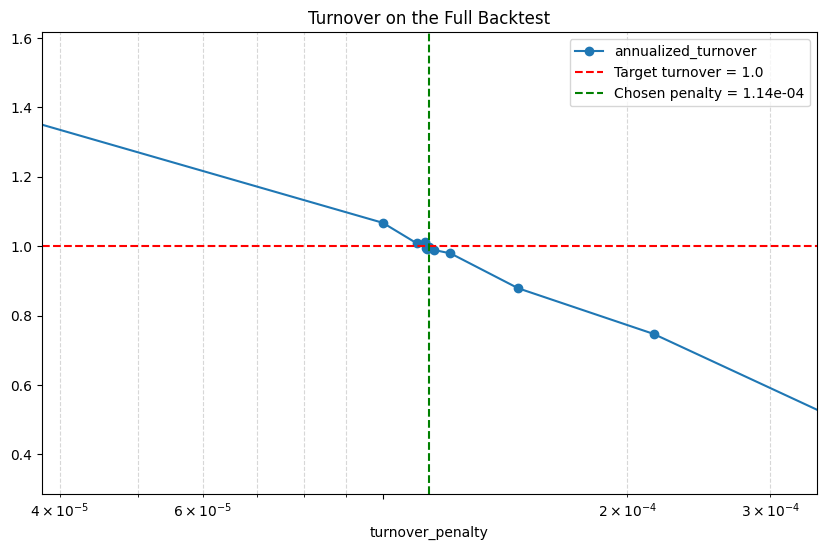

In [32]:
# Plot the refined search region and validate the chosen penalty on the
# final full backtest.

x_min = max(deep_df['turnover_penalty'].min(), best_turnover_penalty / 3)
x_max = min(deep_df['turnover_penalty'].max(), best_turnover_penalty * 3)
y_min = min(deep_df['annualized_turnover'].min(), target_turnover) - 0.1
y_max = max(deep_df['annualized_turnover'].max(), target_turnover) + 0.1

ax = deep_df.plot(
    x='turnover_penalty',
    y='annualized_turnover',
    marker='o',
    logx=True,
    figsize=(10, 6),
    title='Annualized Turnover vs Turnover Penalty',
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.axhline(target_turnover, color='red', linestyle='--', label='Target turnover = 1.0')
ax.axvline(best_turnover_penalty, color='green', linestyle='--', label=f'Chosen penalty = {best_turnover_penalty:.2e}')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    turnover_penalty=float(best_turnover_penalty),
    risk_aversion=1.0,
    max_iter=refinement_max_iter,
    tol=refinement_tol,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

return_series = search_return_series
to_ms = bt_ms.strategy.turnover(return_series=return_series)
annualized_turnover_full = to_ms.iloc[1:].mean() * search_rebal_per_year

print(f'Penalty used in the full backtest: {best_turnover_penalty:.8f}')
print(f'Annualized turnover on the full backtest: {annualized_turnover_full:.4f}')

to_ms.plot(title='Turnover on the Full Backtest', figsize=(10, 6))


## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


<Axes: title={'center': 'Cumulative Performance'}>

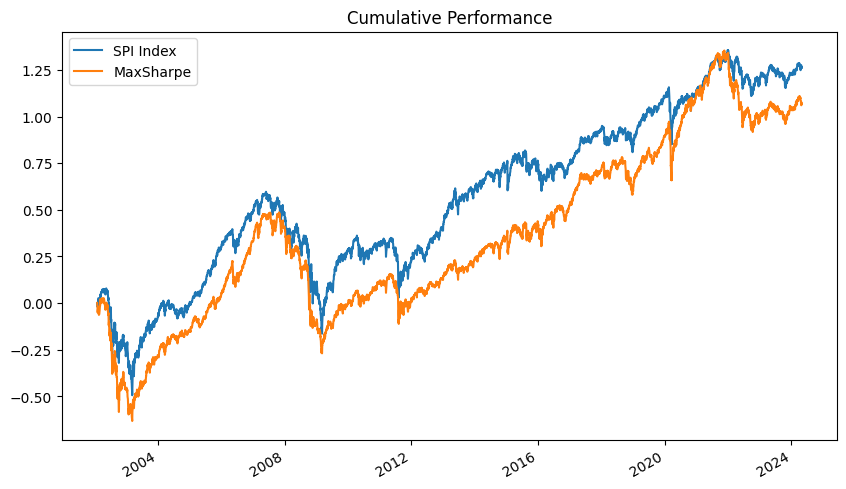

In [33]:
fixed_costs = 0.01
variable_costs = 0.003
return_series = bs.data.get_return_series(weekdays_only=False)

# Compute the portfolio returns locally because the current
# Strategy.simulate() implementation applies costs with integer labels.
sim_segments = []
sim_rebdates = bt_ms.strategy.get_rebalancing_dates()

for rebdate in sim_rebdates:
    next_rebdate = (
        sim_rebdates[sim_rebdates.index(rebdate) + 1]
        if rebdate < sim_rebdates[-1]
        else return_series.index[-1]
    )

    portfolio = bt_ms.strategy.get_portfolio(rebdate)
    w_float = portfolio.float_weights(
        return_series=return_series,
        end_date=next_rebdate,
        rescale=False,
    )
    sim_segments.append(w_float.sum(axis=1).pct_change(1))

sim_ms = pd.concat(sim_segments).dropna()

turnover_for_costs = bt_ms.strategy.turnover(
    return_series=return_series,
    rescale=False,
)
varcost = turnover_for_costs * variable_costs
sim_ms.iloc[0] -= varcost.iloc[0]
sim_ms.loc[varcost.index[1:]] -= varcost.iloc[1:].to_numpy()

n_days = (
    sim_ms.index[1:] - sim_ms.index[:-1]
).to_numpy().astype('timedelta64[D]').astype(int)
fixcost = (1 + fixed_costs) ** (n_days / 252) - 1
sim_ms.iloc[1:] -= fixcost

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

sim.columns = ['SPI Index', 'MaxSharpe']

# Plot the cumulative returns of the strategy and the benchmark
np.log(1 + sim).cumsum().plot(title='Cumulative Performance', figsize=(10, 6))

<Axes: title={'center': 'Turnover'}>

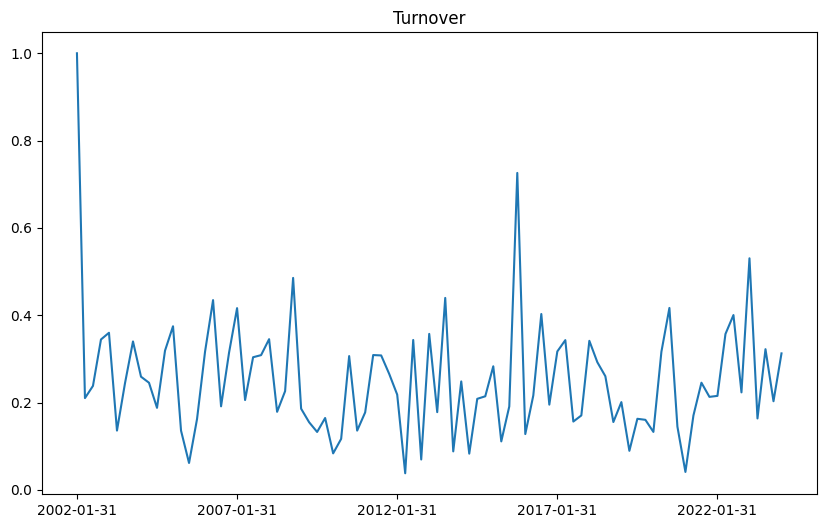

In [34]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [35]:
# Annualized turnover per annum (pa) in percentage
rebdates_dt = pd.to_datetime(rebdates)
rebal_per_year = 365.25 / np.median(
    np.diff(rebdates_dt).astype('timedelta64[D]').astype(int)
)
to_pa = to_ms.iloc[1:].mean() * rebal_per_year * 100
print(f"The annualized turnover is: {to_pa}%")


The annualized turnover is: 96.92704887198254%


In [36]:
# Descriptive analysis

def annualized_return(series, periods_per_year=252):
    series = series.dropna()
    if series.empty:
        return np.nan
    wealth = (1 + series).prod()
    return wealth ** (periods_per_year / len(series)) - 1

def cumulative_return(series):
    series = series.dropna()
    if series.empty:
        return np.nan
    return (1 + series).prod() - 1

def annualized_volatility(series, periods_per_year=252):
    series = series.dropna()
    if len(series) < 2:
        return np.nan
    return series.std(ddof=1) * np.sqrt(periods_per_year)

def sharpe_ratio(series, periods_per_year=252):
    vol = annualized_volatility(series, periods_per_year=periods_per_year)
    if pd.isna(vol) or vol == 0:
        return np.nan
    return series.dropna().mean() / series.dropna().std(ddof=1) * np.sqrt(periods_per_year)

def max_drawdown(series):
    series = series.dropna()
    if series.empty:
        return np.nan
    wealth_index = (1 + series).cumprod()
    running_peak = wealth_index.cummax()
    drawdown = wealth_index / running_peak - 1
    return drawdown.min()

stats = {}
for column in sim.columns:
    series = sim[column].dropna()
    stats[column] = {
        'Annual Return': annualized_return(series),
        'Cumulative Return': cumulative_return(series),
        'Annual Volatility': annualized_volatility(series),
        'Sharpe Ratio': sharpe_ratio(series),
        'Max Drawdown': max_drawdown(series),
    }

stats_df = pd.DataFrame(stats).round(4)
display(stats_df)


,SPI Index,MaxSharpe
Annual Return,0.0556,0.0469
Cumulative Return,2.5325,1.9102
Annual Volatility,0.1647,0.1442
Sharpe Ratio,0.4114,0.3902
Max Drawdown,-0.5325,-0.5301
